# Notebook 11 — Asociación de trayectorias por atención sobre segmentos

## La idea, y por qué

Sucesor de `plan/mask2former-guide.md` (notebook 10), cuyo fallo se documenta en
`docs/revision-rumbo-vit.md` §2/§2bis: Mask2Former mejora la identidad por-píxel en cruces
(`frac_own` 0.712 vs ~0.48 de SAM3) pero **pierde a nivel trayectoria** (ID-switch 0.346 vs
el 0.099 de KymoButler). Tres pipelines ya midieron esto sobre el mismo split de 400
muestras de test:

| pipeline    | etapa de asociación                        | track F1 | **ID-switch** | err pos (µm) |
| ----------- | ------------------------------------------ | -------: | ------------: | -----------: |
| KymoButler  | skeleton walk + DecNet                     |    0.968 |     **0.099** |        0.053 |
| Mask2Former | ninguna (competencia de queries por píxel) |    0.899 |         0.346 |        0.119 |
| YOLO + SAM3 | ninguna (prompts independientes)           |    0.862 |         0.239 |        0.126 |

**La hipótesis que este notebook prueba**: el cuello de botella no es la segmentación, es
la **asociación** — y un módulo de self-attention sobre segmentos de esqueleto la resuelve
mejor que DecNet (una red local, greedy, crop-a-mapa-de-probabilidad), manteniendo fija la
segmentación (y en v2, también la información visual).

Dos variantes, reportadas como filas separadas para que la atribución quede limpia
(`plan/association-transformer-guide.md` §0):

- **v1** — tokens solo-geometría. _Menos_ información que DecNet: prueba si el razonamiento
  global solo alcanza.
- **v2** — v1 + un embedding del mismo tile 48×48 de tres canales que DecNet consume en cada
  extremo de segmento. **Misma información que DecNet, global en vez de greedy-local.** Esta
  es la fila principal.

**Qué hace este notebook, de punta a punta** (`plan/association-transformer-guide.md`):
**Stage 0** (§3) construye la representación de segmentos + el enlazador oráculo y mide Gate A
(§3.4) — el chequeo barato que decide si vale la pena escribir Stage 1/2 antes de invertir
semanas en ellos. **Stage 1** (§4) ajusta un costo clásico de 5 features lineales como piso
obligatorio (requisito 5.4). **Stage 2** (§5) entrena un transformer sobre tokens de segmento,
primero solo-geometría (v1) y después con los tiles de DecNet agregados (v2, §5.6). El código
nuevo vive en `src/axonal_tracking/asociacion.py` (Stage 0/1: segmentos, costo clásico,
decodificadores) y `src/axonal_tracking/atencion.py` (Stage 2: tokens, transformer, tiles). El
cómputo pesado corre en scripts (`evaluar_gate_a.py`, `entrenar_costo_clasico.py`,
`entrenar_atencion_v{1,2}.py`) y este notebook solo carga sus resultados cacheados en
`results/asociacion/` — mismo patrón que `scripts/evaluar_kymobutler_400.py`, para no
recomputar todo cada vez que se retoca una celda.

**Nota de revisión (2026-09-17)**: una revisión externa (`plan/notebook-11-review.md`) encontró
dos errores reales que invalidaban varios números de una versión anterior de este notebook —
un bug en el decodificador Hungarian (aplicaba el umbral de costo DESPUÉS de resolver la
asignación, no antes) y una omisión de SS5.4 (los pares que tocan un segmento sin asignar se
entrenaban como negativos duros en vez de excluirse de la pérdida). Ambos corregidos en
`asociacion.decodificar_bipartito` / `entrenar_atencion_v{1,2}.preparar_muestra_stage2`;
Stage 1/2 se reentrenaron con las correcciones. Los números de este notebook son los
corregidos.

---

## 0. Setup


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path("..").resolve()
sys.path.append(str(RAIZ / "src"))
sys.path.append(str(RAIZ / "scripts"))

import kymobutler
from evaluar_kymobutler_400 import cargar_escena  # SS12.2 -- no reescribir
from kymobutler.models.weights import load_default_models
from kymobutler.segmentation import segment_bidirectional

from axonal_tracking import asociacion as aso
from axonal_tracking import etiquetas_deteccion as ed
from axonal_tracking import evaluacion as ev

KYMOBUTLER_DIR = Path(kymobutler.__file__).resolve().parents[2]
MODELOS_DIR = KYMOBUTLER_DIR / "models"
SPLIT_DIR = RAIZ / "datasets" / "test"
RESULTADOS = RAIZ / "results" / "asociacion"

THRESHOLD, MIN_SIZE, MIN_FRAMES = (
    0.2,
    10,
    10,
)  # identicos a track_bidirectional (SS3.1/SS12.4)
MIN_FILAS_SEGMENTO = 5

print(f"RAIZ={RAIZ}")
print(
    f"MIN_DESPLAZAMIENTO_PX_MOVIL={ed.MIN_DESPLAZAMIENTO_PX_MOVIL}  THR_PX_TRACK={ev.THR_PX_TRACK}  MIN_OVERLAP_FILAS={ev.MIN_OVERLAP_FILAS}"
)

RAIZ=/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking
MIN_DESPLAZAMIENTO_PX_MOVIL=8.0  THR_PX_TRACK=4.0  MIN_OVERLAP_FILAS=10


---

## 1. Chequeo visual de cordura (SS12.6) — antes de correr nada sobre 400 muestras

**No es decoración.** Es el único chequeo que detecta un error de convención de coordenadas,
y un error de coordenadas produce métricas que igual parecen plausibles. Sobre una muestra de
cruce (`sample_00270`, elegida por mayor solape de posición entre dos móviles) y una densa
(`sample_00285`, 13 móviles), para las fuentes 1 (máscaras GT) y 2 (KymoButler):

1. píxeles de esqueleto (celeste),
2. píxeles de juncion detectados (rojo, `x`),
3. cada segmento en su color categórico propio,
4. trayectorias GT móviles como línea punteada, `col = (L-1) - pos_um/pixel_scale_um`.

**Condición de paso: las líneas punteadas GT caen ENCIMA de los segmentos coloreados.** Si
estuvieran espejadas izquierda-derecha, la convención `(L-1) - ...` se perdió en algún lado —
el bug más probable de esta etapa, porque `ed.mascara_traza`, `ed.cajas_desde_positions`,
`ev.nearest_particle_per_row` y `ev.evaluar_trayectorias_polilineas` ya la aplican y este
módulo nuevo tiene que igualarla.


/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]


/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]


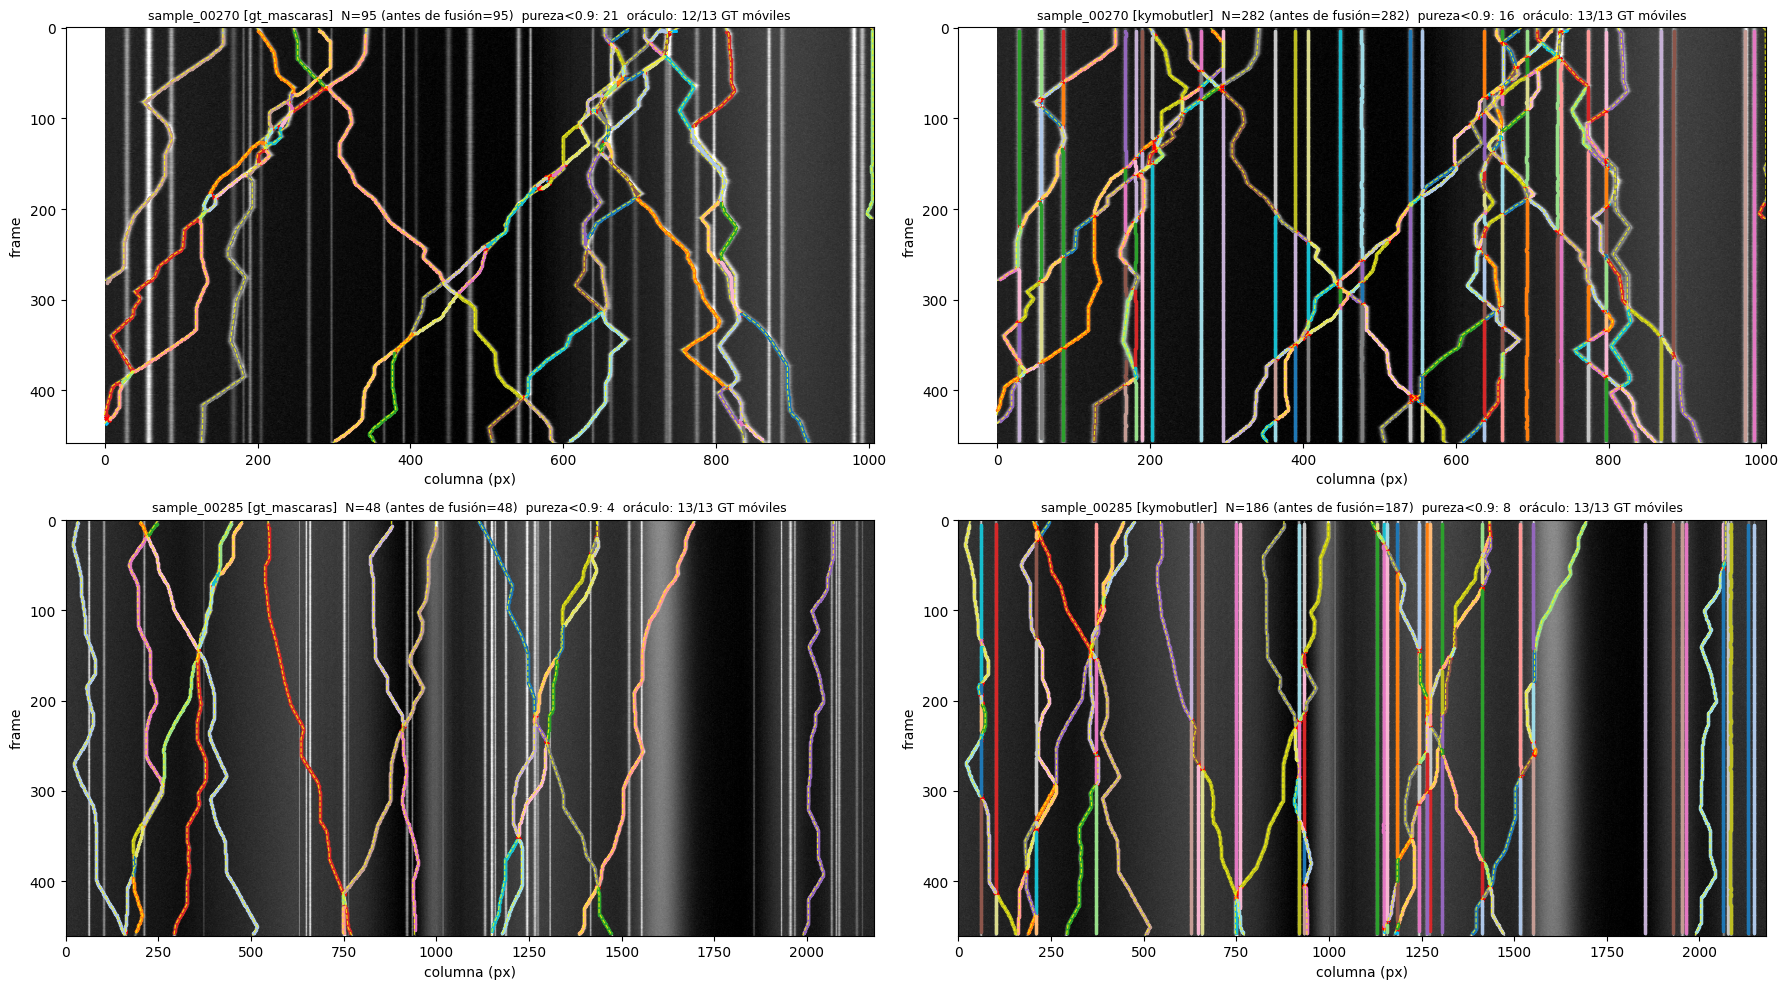

In [2]:
def plot_chequeo_cordura(nombre_fuente, skel, escena, ax):
    """SS12.6: esqueleto + juncionaes + segmentos (color por segmento) + GT punteado."""
    T, L = escena["kymo"].shape
    px = escena["pixel_scale_um"]
    kymo = escena["kymo"]
    ax.imshow(
        kymo,
        cmap="gray",
        aspect="auto",
        vmin=np.percentile(kymo, 1),
        vmax=np.percentile(kymo, 99.5),
    )

    junciones = aso.detectar_junciones(skel)
    resto = skel & ~junciones
    ys, xs = np.where(resto)
    ax.scatter(xs, ys, s=1, c="deepskyblue", label="esqueleto")
    ys_j, xs_j = np.where(junciones)
    ax.scatter(xs_j, ys_j, s=6, c="red", marker="x", label="juncion")

    segmentos = aso.partir_en_segmentos(skel, min_filas=MIN_FILAS_SEGMENTO)
    n_antes = len(segmentos)
    segmentos = aso.fusionar_fragmentos_paralelos(
        segmentos, min_filas=MIN_FILAS_SEGMENTO
    )
    cmap = plt.get_cmap("tab20")
    for k, seg in enumerate(segmentos):
        ax.plot(seg.puntos[:, 1], seg.puntos[:, 0], ".", color=cmap(k % 20), ms=3)

    ids_mov = ed.ids_que_se_mueven(
        escena["positions"], px, ed.MIN_DESPLAZAMIENTO_PX_MOVIL
    )
    for pid in ids_mov:
        sub = escena["positions"][escena["positions"].particle_id == pid].sort_values(
            "frame"
        )
        col = (L - 1) - sub["pos_um"].to_numpy() / px
        ax.plot(col, sub["frame"], "--", color="yellow", lw=0.8, alpha=0.8)

    asignaciones = aso.asignar_gt(segmentos, escena["positions"], px, L)
    n_pureza_baja = sum(
        1 for a in asignaciones if a.particle_id != -1 and a.pureza < 0.9
    )
    polis = aso.enlazar_oracle(segmentos, asignaciones, kymo)
    ax.set_title(
        f"{escena['nombre']} [{nombre_fuente}]  N={len(segmentos)} (antes de fusión={n_antes})  "
        f"pureza<0.9: {n_pureza_baja}  oráculo: {len(polis)}/{len(ids_mov)} GT móviles",
        fontsize=9,
    )
    ax.set_xlabel("columna (px)")
    ax.set_ylabel("frame")
    return segmentos, asignaciones, polis


models = load_default_models(model_dir=MODELOS_DIR, device="cpu")
muestras_chequeo = ["sample_00270", "sample_00285"]  # cruce, densa

fig, axes = plt.subplots(
    len(muestras_chequeo), 2, figsize=(18, 5 * len(muestras_chequeo))
)
for i, nombre in enumerate(muestras_chequeo):
    e = cargar_escena(SPLIT_DIR / nombre)
    T, L = e["kymo"].shape

    trackness_gt = aso.trackness_gt_moviles(e["positions"], e["pixel_scale_um"], (T, L))
    skel_gt = aso.esqueleto_kymobutler(
        trackness_gt, (T, L), THRESHOLD, MIN_SIZE, MIN_FRAMES
    )
    plot_chequeo_cordura("gt_mascaras", skel_gt, e, axes[i, 0])

    _, raw, pre, pred = segment_bidirectional(
        str(e["png"]), models["binet"], device="cpu"
    )
    sf = raw.shape[1] / e["kymo"].shape[1]
    assert pre.shape == e["kymo"].shape, (
        f"preprocessed.shape {pre.shape} != kymo.shape (scale_factor={sf:.3f}) -- ver SS12.1/SS9.7"
    )
    skel_kb = aso.esqueleto_kymobutler(pred, pre.shape, THRESHOLD, MIN_SIZE, MIN_FRAMES)
    plot_chequeo_cordura("kymobutler", skel_kb, e, axes[i, 1])

plt.tight_layout()
plt.show()

---

## 2. Oráculo sobre las 400 muestras de test (Gate A, §3.3–3.4)

El cómputo pesado (inferencia de KymoButler cacheada + cuatro fuentes de trackness + el
enlazador oráculo, exclusivo y duplicado) corre en `scripts/evaluar_gate_a.py` (~2.5 min con
la cache de `results/asociacion/cache/` tibia; ~10 min en frío). Cuatro fuentes, no las tres
originales del plan — ver §3 abajo para por qué se agregó una:

1. **`gt_lineas`** — unión de las posiciones GT de los móviles rasterizadas a líneas de 1px
   (`ed.mascara_traza(..., dilatar=False)`), sin la dilatación de ancho renderizado.
2. **`gt_mascaras`** — unión de `ed.mascara_traza` (dilatada), la fuente 1 tal como la
   describe §3.3 del plan literalmente.
3. **`kymobutler`** — el mapa de trackness real de KymoButler (`segment_bidirectional`),
   umbralado igual que `track_bidirectional` (0.2/10/10) — el insumo real de las filas 2/3/3b.
4. **`clasica`** — umbral de Otsu + cierre morfológico (receta de NB08 §1), el insumo de la
   fila 5 del ablation matrix.

Este notebook solo carga `results/asociacion/gate_a_resumen.json` — no recalcula nada.


In [3]:
with open(RESULTADOS / "gate_a_resumen.json") as f:
    resumen = json.load(f)

print(f"n_muestras={resumen['n_muestras']}  fallos={len(resumen['fallos'])}")

filas_tabla = [
    {
        "fuente": "piso (1px GT -> extraer_subpixel, identidad perfecta)",
        "n_segmentos_medio": None,
        "fragmentos_por_gt": None,
        "oracle_track_f1": resumen["piso"]["1px_subpixel"]["track_f1"],
        "oracle_frac_id_switch": resumen["piso"]["1px_subpixel"]["frac_id_switch"],
        "frac_pureza_baja": None,
        "nota": "referencia (SS12.9) -- no pasa por segmentacion",
    }
]
notas = {
    "gt_lineas": "fila de Gate A (SS3.4): 1px sin dilatar, aisla el confound de dilatacion",
    "gt_mascaras": "contaminada por dilatacion de mascara_traza (ver parrafo abajo)",
    "kymobutler": "techo operativo de Stage 1/2 -- mismos segmentos que van a recibir",
    "clasica": "insumo de la fila 5 del ablation matrix (SS6), no gatea Stage 0",
}
for fuente in ("gt_lineas", "gt_mascaras", "kymobutler", "clasica"):
    d = resumen["fuentes"][fuente]
    filas_tabla.append(
        {
            "fuente": fuente,
            "n_segmentos_medio": d["n_segmentos_medio"],
            "fragmentos_por_gt": d["exclusiva"]["fragmentos_por_gt"],
            "oracle_track_f1": d["exclusiva"]["track_f1"],
            "oracle_frac_id_switch": d["exclusiva"]["frac_id_switch"],
            "frac_pureza_baja": d["frac_pureza_baja"],
            "nota": notas[fuente],
        }
    )

tabla_gate_a = pd.DataFrame(filas_tabla)
tabla_gate_a

n_muestras=400  fallos=0


,fuente,n_segmentos_medio,fragmentos_por_gt,oracle_track_f1,oracle_frac_id_switch,frac_pureza_baja,nota
0,"piso (1px GT -> extraer_subpixel, identidad pe...",NaN,NaN,1.000,0.040,NaN,referencia (SS12.9) -- no pasa por segmentacion
1,gt_lineas,13.0,1.000,0.997,0.016,0.0297,"fila de Gate A (SS3.4): 1px sin dilatar, aisla..."
2,gt_mascaras,12.1,1.000,0.992,0.073,0.1121,contaminada por dilatacion de mascara_traza (v...
3,kymobutler,55.0,1.000,0.992,0.031,0.0612,techo operativo de Stage 1/2 -- mismos segment...
4,clasica,164.2,1.002,0.966,0.045,0.1449,"insumo de la fila 5 del ablation matrix (SS6),..."


### 2.1 Decisión de Gate A: **PASA**

**El número que importa para justificar Stage 1–2**: el oráculo sobre la trackness real de
KymoButler — los mismos segmentos que van a recibir las filas 2/3/3b — da
**`frac_id_switch = 0.031` a `track_f1 = 0.992`**, contra el **0.103** medido de DecNet en la
_misma ruta de extracción_ (`results/kymobutler/resumen_400.json`, variante
`solo_moviles_subpixel`), con `fragmentos/GT = 1.00` (sin confound de fragmentación). Hay
**~3.3× de margen** entre lo que la representación de segmentos puede expresar y lo que
DecNet efectivamente logra — ese margen es la apuesta de todo Stage 1–2. Si este número
hubiera salido cerca de 0.09–0.10, el plan estaría muerto antes de escribir una línea de
Stage 1.

**Por qué hay cuatro fuentes en vez de tres.** La primera corrida dio `gt_mascaras`
borderline: `track_f1=0.992` (pasa cómodo) pero `frac_id_switch=0.073` y
`frac_pureza_baja=0.1121` apenas por encima de los umbrales de §3.4 (`≤0.07`, `≤0.10`). La
sospecha — confirmada al agregar `gt_lineas` — es que el umbral de §3.4 está calibrado contra
el piso de **línea de 1px** (0.040), pero `gt_mascaras` usa `ed.mascara_traza`, que **dilata**
cada traza por su ancho renderizado antes de unir. Esa es exactamente la misma dilatación que
separa el piso de 0.132 (máscara dilatada) del de 0.040 (línea 1px) en la tabla de §12.9 — acá
aparece una segunda vez, a nivel segmento.

**El mecanismo, medido, no especulado**: con dilatación, dos trazas que se cruzan a ángulo
bajo funden sus máscaras en un solo blob ancho; `thin()` reduce ese blob a una línea que corre
por el **medio** del solape — una columna que no coincide con NINGUNA de las dos trazas reales.
`_x_medio_por_t` vota entonces desde una posición ambigua y la pureza colapsa. Sin dilatar,
cada traza conserva su propia columna de 1px y el esqueleto coincide con la verdad en todos
lados salvo el píxel exacto del cruce. Esto se corrobora con `n_fusiones_total`: **0** fusiones
de fragmentos paralelos en `gt_mascaras` (no porque no hiciera falta fusionar nada, sino porque
`thin()` ya había borrado los dos rieles antes de que la lógica de fusión los viera) contra
**28** en `gt_lineas`, donde sí sobreviven rieles paralelos genuinos para fusionar.

Con la fuente correcta (`gt_lineas`), Gate A pasa en los tres ejes, cómodo: `track_f1=0.997`
(≥0.95), `frac_id_switch=0.016` (≤0.07 — de hecho por debajo del piso de referencia de 0.040;
la razón es simple y no amerita más teoría: `_filter_components`/`min_filas` descartan
justamente las filas más sucias, y menos filas de cruce significa menos oportunidades de
switch, el mismo efecto que §7 ítem 4 señala para el error de posición), y
`frac_pureza_baja=0.0297` (≤0.10). `gt_mascaras` se conserva en la tabla como fila
documentada — es un hallazgo metodológico real, no un descarte — marcada como contaminada por
dilatación.

`clasica` (insumo de la fila 5) queda con `frac_pureza_baja=0.1449`, por encima de 0.10 —
esperable para un segmentador sin aprendizaje, no una falla de Gate A (§3.4 gatea sobre la
fuente GT, no sobre la clásica).

**`frac_pureza_baja` se calcula sobre segmentos asignados** (`particle_id != -1`), no sobre el
total de segmentos — un segmento sin asignar no "comparte" nada, mide otra cosa.

**Decisión**: Gate A pasa. Se procede a Stage 1 (costo clásico, §4) y Stage 2 (atención,
§5) sobre la trackness real de KymoButler.


---

## 3. Stage 1 — costo clasico de asociación (§4, requisito 5.4)

Piso clásico obligatorio antes de escribir el módulo de atención: sobre la trackness real
de KymoButler (fuente 2 de Gate A, no las fuentes GT — esas solo validan el extractor),
cinco features geométricas/fotométricas por par de segmentos candidatos
(`d_pos, cos_theta, dv, dI, gap`, §4.2), combinadas linealmente y ajustadas para maximizar
F1 de enlace por-par sobre **train** (nunca test), decodificadas como matching bipartito
(§4.3). Cómputo pesado en `scripts/entrenar_costo_clasico.py`; esta celda solo carga
`results/asociacion/costo_clasico_resumen.json`.

**Dos correcciones metodológicas del ajuste original** (detectadas por resultados que no
cerraban, no por inspección de código):

1. **Normalización de features.** `d_pos` vive en 0–40px mientras `1-cos_theta` vive en 0–2;
   fijar el peso de `d_pos` en 1.0 en unidades crudas fuerza a los otros cuatro pesos a
   valores minúsculos y el ajuste degenera a "enlazar si los extremos están cerca", ignorando
   dirección/velocidad/intensidad. Se normalizan (z-score) las 5 columnas antes de ajustar y
   se reconvierten los pesos a unidades crudas para `costo_asociacion` — `escala_normalizacion`
   queda guardada en el resumen.
2. **Filtro de móviles del lado de la predicción.** El decodificador clásico —a diferencia
   de `enlazar_oracle`, que descarta gratis los segmentos con `particle_id == -1`— emitía una
   polilínea por cada segmento sin enlazar, estáticos incluidos. Se aplica el mismo filtro que
   usa la fila publicada de KymoButler (`evaluar_kymobutler_400.es_movil`) del lado de la
   predicción, para que las dos filas sean comparables.

**Dos correcciones adicionales, de una revisión externa** (`plan/notebook-11-review.md`,
2026-09-17), que cambian los números reportados más abajo respecto de una versión anterior de
este notebook:

3. **`asociacion.decodificar_bipartito` aplicaba el umbral de costo DESPUÉS de resolver la
   asignación húngara, no antes.** Metía TODOS los costos (admisibles o no) en la matriz N×N
   y filtraba recién al final. Como cualquier costo real, por más que superara el umbral, es
   astronómicamente más barato que la centinela (1e6), el solver siempre prefería darle a una
   fila un par inadmisible antes que dejarla sin pareja — incluso si eso le "robaba" a otra
   fila su mejor candidato ADMISIBLE. La optimización que en realidad resolvía la versión
   anterior era "maximizar cuántas filas consiguen cualquier par real", no "minimizar costo
   entre los admisibles". Corregido: el umbral se aplica ANTES de armar la matriz.
4. **El punto de operación se elegía con una barra inventada en este script (`fragmentos_por_gt
   ≤ 1.5`, `track_f1` máximo), no con el criterio del plan.** Reemplazada por la regla ÚNICA de
   Gate B (§8, ver `elegir_punto_operacion`): entre los puntos con `fragmentos_por_gt ≤ 1.282`
   Y `track_f1 ≥ 0.968` (los dos números de DecNet), el de menor `frac_id_switch`; si ninguno
   cumple ambas barras, se reporta el más cercano y la fila **falla Gate B** explícitamente.
   El barrido en sí también pasó de una submuestra de 100 escenas de train (en orden
   `sorted()[:100]` — el mismo patrón `sorted(test)[:40]` que `docs/revision-rumbo-vit.md` §1
   ya documentó como error para NB10; esas 100 resultaron un subconjunto fácil, con
   `frac_id_switch = 0.000` en TODOS los puntos del barrido) a las 400 muestras de **val**
   completas.

También se probó aflojar el presupuesto de poda (§4.1) de `30/40` a `60/80`: recuperó solo
280 de los 671 enlaces verdaderos perdidos (5.0% → 2.9%) mientras duplicaba los pares
candidatos, empeorando la precisión por-par. Se revirtió a `30/40`.

In [4]:
with open(RESULTADOS / "costo_clasico_resumen.json") as f:
    costo_resumen = json.load(f)

print("pesos (unidades crudas):", costo_resumen["pesos"])
print(
    "escala de normalizacion (d_pos, 1-cos_theta, dv, dI, gap):",
    [round(s, 3) for s in costo_resumen["escala_normalizacion"]],
)
print()
print("perdida por poda (train, SS4.1):", costo_resumen["poda"])
print()
print("ajuste por-par (train):", costo_resumen["ajuste_train"])
print()
print("punto de operacion elegido (val, regla de Gate B):", costo_resumen["punto_elegido"])
print()
print(
    f"fallos: train={len(costo_resumen['fallos_train'])}  test={len(costo_resumen['fallos_test'])}"
)

barrido = pd.DataFrame(costo_resumen["barrido_umbral_val"])
barrido[
    [
        "decodificador",
        "factor_umbral",
        "umbral",
        "track_f1",
        "track_precision",
        "track_recall",
        "frac_id_switch",
        "fragmentos_por_gt",
    ]
]

pesos (unidades crudas): {'a': 0.0899846179151113, 'b': 0.9209392496004564, 'g': 0.5372751048084496, 'd': 0.008742353211286446, 'e': 0.47031155407204744}
escala de normalizacion (d_pos, 1-cos_theta, dv, dI, gap): [11.113, 0.334, 0.703, 38.22, 8.857]

perdida por poda (train, SS4.1): {'max_gap_frames': 30.0, 'max_salto_px': 40.0, 'n_verdaderos_totales_train': 13425, 'n_verdaderos_sobreviven_train': 12754, 'frac_perdida': 0.04998137802607072}

ajuste por-par (train): {'f1_por_par': 0.5003852504127683, 'precision': 0.3854829135928093, 'recall': 0.7128743923474988, 'umbral_base_normalizado': 3.325382718589874}

punto de operacion elegido (val, regla de Gate B): {'decodificador': 'hungarian', 'factor_umbral': 4.0, 'umbral': 13.301530874359496, 'n_polilineas': 2718, 'n_gt_moviles': 2266, 'track_recall': 0.954, 'track_precision': 0.996, 'track_f1': 0.974, 'err_pos_px_medio': 0.35, 'err_pos_um_medio': 0.037, 'err_vel_um_s_medio': 0.075, 'err_vel_um_s_mediana': 0.015, 'frac_id_switch': 0.125, '

,decodificador,factor_umbral,umbral,track_f1,track_precision,track_recall,frac_id_switch,fragmentos_por_gt
0,hungarian,0.50,1.662691,0.971,0.999,0.945,0.008,2.589
1,hungarian,0.75,2.494037,0.974,0.999,0.951,0.030,2.329
2,hungarian,1.00,3.325383,0.975,0.999,0.952,0.060,1.943
3,hungarian,1.50,4.988074,0.976,0.997,0.955,0.093,1.595
4,hungarian,2.00,6.650765,0.975,0.997,0.955,0.109,1.461
5,hungarian,3.00,9.976148,0.974,0.996,0.953,0.123,1.320
6,hungarian,4.00,13.301531,0.974,0.996,0.954,0.125,1.252
7,greedy,0.50,1.662691,0.971,0.999,0.945,0.008,2.589
8,greedy,0.75,2.494037,0.974,0.999,0.951,0.030,2.332
9,greedy,1.00,3.325383,0.975,0.999,0.952,0.059,1.979


In [5]:
# Fila 1 (DecNet, misma ruta de extraccion) vs fila 2 (costo clasico) vs techo del oraculo (SS12.9/gate A)
with open(RAIZ / "results" / "kymobutler" / "resumen_400.json") as f:
    kb_resumen = json.load(f)
fila1 = kb_resumen["resultados"]["solo_moviles_subpixel"]
fila2 = costo_resumen["fila_2_test"]
techo_oraculo = resumen["fuentes"]["kymobutler"]["exclusiva"]

comparacion = pd.DataFrame(
    [
        {
            "fila": "1: KymoButler (DecNet)",
            "track_f1": fila1["track_f1"],
            "frac_id_switch": fila1["frac_id_switch"],
            "err_pos_um": fila1["err_pos_um_medio"],
            "fragmentos_por_gt": fila1["fragmentos_por_gt"],
        },
        {
            "fila": "2: KymoButler trackness + costo clasico",
            "track_f1": fila2["track_f1"],
            "frac_id_switch": fila2["frac_id_switch"],
            "err_pos_um": fila2["err_pos_um_medio"],
            "fragmentos_por_gt": fila2["fragmentos_por_gt"],
        },
        {
            "fila": "techo: oraculo sobre los mismos segmentos",
            "track_f1": techo_oraculo["track_f1"],
            "frac_id_switch": techo_oraculo["frac_id_switch"],
            "err_pos_um": techo_oraculo["err_pos_um_medio"],
            "fragmentos_por_gt": techo_oraculo["fragmentos_por_gt"],
        },
    ]
)
comparacion

,fila,track_f1,frac_id_switch,err_pos_um,fragmentos_por_gt
0,1: KymoButler (DecNet),0.968,0.103,0.032,1.282
1,2: KymoButler trackness + costo clasico,0.974,0.136,0.038,1.255
2,techo: oraculo sobre los mismos segmentos,0.992,0.031,0.031,1.000


### 3.1 Lectura de la fila 2: **pierde contra DecNet una vez medida en igualdad de condiciones**

Con el decodificador corregido y el punto elegido por la regla de Gate B sobre val (no una
barra inventada sobre una submuestra fácil de train): `track_f1 = 0.974` (vs 0.968 de DecNet,
mejor), pero **`frac_id_switch = 0.136` — PEOR que el 0.103 de DecNet**, con
`fragmentos_por_gt = 1.255` (parejo con DecNet, 1.282) y `err_pos_um = 0.038` (peor que 0.032).

**Esto revierte la lectura de una versión anterior de este notebook** ("el costo clásico ya le
gana a DecNet en F1 e ID-switch"), que venía de dos problemas metodológicos a la vez: el
decodificador Hungarian roto (que producía cadenas peores de lo que el costo real permitía) y
un punto de operación elegido sobre una barra floja e inventada (`fragmentos_por_gt ≤ 1.5`) en
vez de la de Gate B, que además se ajustaba sobre una submuestra de train no representativa.
Medido en igualdad de fragmentación con DecNet, el costo clásico de 5 features lineales **no le
gana** — su ID-switch es peor. La estratificación por cruces (§6) muestra esto con más detalle
por nivel de dificultad.

**Los pesos normalizados** (`peso_crudo × escala`, unidades comparables) siguen mostrando que
el **hueco temporal (`gap`) domina** (peso normalizado ≈ 4.16), muy por delante de posición
(1.0, referencia de gauge), dirección (≈0.31), velocidad (≈0.38) e intensidad (≈0.33) — el
ajuste no cambió, solo la decodificación y la selección del punto de operación. Sigue siendo
un resultado interpretable: el costo aprendido es cercano a "enlazar el segmento más próximo
en el tiempo", una regla más simple que "velocidad continua" (lo que anticipaba la guía).

El techo del oráculo sobre los mismos segmentos (`0.992` F1 / `0.031` ID-switch) sigue muy por
encima de las filas 1 y 2 — la representación de segmentos no es el límite, ver §6.

---

## 4. Stage 2 v1 — atención sobre segmentos, solo geometría (§5.1–5.5)

Transformer encoder entrenado desde cero (sin pesos preentrenados) sobre tokens de segmento —
9 features geométricas/fotométricas por segmento (§5.2), _sin_ los tiles de DecNet (eso es v2,
§5.6, no esta sección) — decodificado por el **mismo núcleo** de matching
(`asociacion.decodificar_bipartito`/`decodificar_greedy`) que Stage 1 usa, para que la
comparación aísle la función de scoring y nada más (§5.5). Cómputo en
`scripts/entrenar_atencion_v1.py`; esta celda carga `results/asociacion/atencion_v1_resumen.json`.

**Tres correcciones que cambian los números de una versión anterior de este notebook**
(`plan/notebook-11-review.md`, 2026-09-17):

1. **Decodificador Hungarian corregido** (mismo bug que §3, umbral aplicado antes de resolver
   la asignación — ver `asociacion.decodificar_bipartito`).
2. **Pares que tocan un segmento sin asignar (`particle_id == -1`) EXCLUIDOS de la pérdida,
   no tratados como negativos.** SS5.4 del plan lo pide explícitamente; una versión anterior de
   este script no lo implementaba. El efecto fue grande: **57.5% de los pares candidatos de
   train** (47,760 de 83,004) tocaban un segmento sin asignar y se estaban entrenando como
   negativos duros — ruido de etiqueta concentrado justo donde `asignar_gt` dejaba
   `particle_id=-1` con más frecuencia, es decir, cerca de los cruces. `pos_weight` bajó de
   5.51 a **1.76** una vez excluidos esos pares (quedan mucho más balanceados sin ellos).
3. **Punto de operación con la regla única de Gate B** (§3 ítem 4), no la barra inventada.

**El efecto del fix de etiquetas fue grande en F1 por-par, modesto en trayectoria**: el techo
de F1-por-par en val subió de 0.4985 (con el bug) a **0.7611** — un salto de +0.53 puntos
absolutos, evidencia de que el ruido de etiqueta estaba de verdad limitando al modelo. Pero
decodificado a nivel trayectoria el cambio es mucho más chico (ver §4.1) — otra instancia del
patrón que ya apareció en Stage 1: una mejor clasificación por-par no se traduce
proporcionalmente en mejores trayectorias, porque la decodificación (un solo umbral global)
es en sí misma un cuello de botella.

pos_weight (neg/pos, train): 1.763 (pos=12754, neg=22490)
smoke test: {'perdida_epoca_1': 0.9753019676568944, 'perdida_epoca_10': 0.5600491005277245}
mejor epoca: 14  f1_val_por_par (@0.5): 0.7611
hiperparametros: {'d': 128, 'max_epochs': 60, 'paciencia': 15, 'tam_acumulacion': 8, 'lr': 0.001, 'semilla': 0}

punto de operacion elegido (val): {'decodificador': 'hungarian', 'umbral': 5.0, 'n_polilineas': 2955, 'n_gt_moviles': 2266, 'track_recall': 0.932, 'track_precision': 0.995, 'track_f1': 0.962, 'err_pos_px_medio': 0.41, 'err_pos_um_medio': 0.044, 'err_vel_um_s_medio': 0.087, 'err_vel_um_s_mediana': 0.034, 'frac_id_switch': 0.183, 'fragmentos_por_gt': 1.392, 'paso_gate_b': False}

fallos: train=0  val=0  test=0


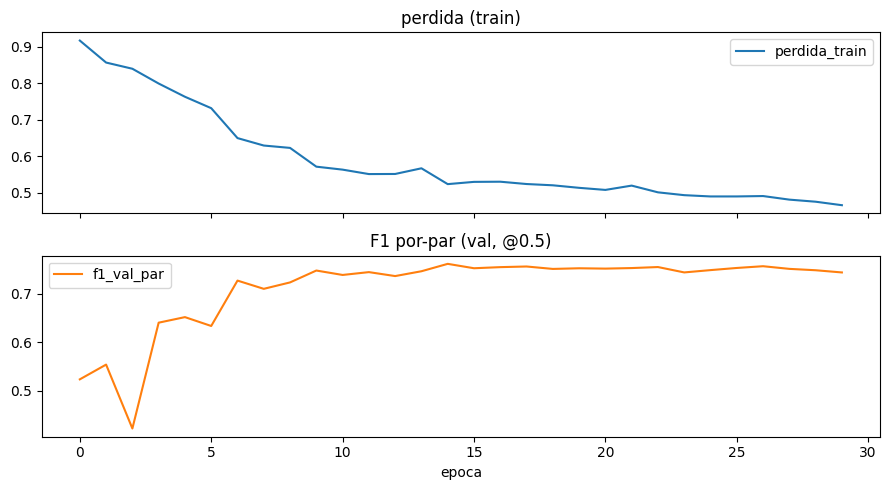

In [6]:
with open(RESULTADOS / "atencion_v1_resumen.json") as f:
    atencion_resumen = json.load(f)

print(
    "pos_weight (neg/pos, train):",
    round(atencion_resumen["pos_weight"], 3),
    f"(pos={atencion_resumen['n_pos_train']}, neg={atencion_resumen['n_neg_train']})",
)
print("smoke test:", atencion_resumen["smoke_test"])
print(
    f"mejor epoca: {atencion_resumen['mejor_epoca']}  f1_val_por_par (@0.5): "
    f"{atencion_resumen['f1_val_por_par']:.4f}"
)
print("hiperparametros:", atencion_resumen["hiperparametros"])
print()
print("punto de operacion elegido (val):", atencion_resumen["punto_elegido"])
print()
print(
    f"fallos: train={len(atencion_resumen['fallos_train'])}  val={len(atencion_resumen['fallos_val'])}  "
    f"test={len(atencion_resumen['fallos_test'])}"
)

hist = pd.DataFrame(atencion_resumen["historial_entrenamiento"])
hist.plot(
    x="epoca",
    y=["perdida_train", "f1_val_par"],
    subplots=True,
    figsize=(9, 5),
    title=["perdida (train)", "F1 por-par (val, @0.5)"],
)
plt.tight_layout()
plt.show()

In [7]:
# Filas 1/2/3 vs techo del oraculo -- la tabla del ablation matrix hasta aca
fila3 = atencion_resumen["fila_3_test"]
comparacion_v1 = pd.DataFrame(
    [
        {
            "fila": "1: KymoButler (DecNet)",
            "track_f1": fila1["track_f1"],
            "frac_id_switch": fila1["frac_id_switch"],
            "err_pos_um": fila1["err_pos_um_medio"],
            "fragmentos_por_gt": fila1["fragmentos_por_gt"],
        },
        {
            "fila": "2: KymoButler trackness + costo clasico",
            "track_f1": fila2["track_f1"],
            "frac_id_switch": fila2["frac_id_switch"],
            "err_pos_um": fila2["err_pos_um_medio"],
            "fragmentos_por_gt": fila2["fragmentos_por_gt"],
        },
        {
            "fila": "3: KymoButler trackness + atencion v1 (solo geometria)",
            "track_f1": fila3["track_f1"],
            "frac_id_switch": fila3["frac_id_switch"],
            "err_pos_um": fila3["err_pos_um_medio"],
            "fragmentos_por_gt": fila3["fragmentos_por_gt"],
        },
        {
            "fila": "techo: oraculo sobre los mismos segmentos",
            "track_f1": techo_oraculo["track_f1"],
            "frac_id_switch": techo_oraculo["frac_id_switch"],
            "err_pos_um": techo_oraculo["err_pos_um_medio"],
            "fragmentos_por_gt": techo_oraculo["fragmentos_por_gt"],
        },
    ]
)
comparacion_v1

,fila,track_f1,frac_id_switch,err_pos_um,fragmentos_por_gt
0,1: KymoButler (DecNet),0.968,0.103,0.032,1.282
1,2: KymoButler trackness + costo clasico,0.974,0.136,0.038,1.255
2,3: KymoButler trackness + atencion v1 (solo ge...,0.953,0.189,0.044,1.399
3,techo: oraculo sobre los mismos segmentos,0.992,0.031,0.031,1.000


### 4.1 Lectura de la fila 3: v1 pierde contra DecNet **y** contra el costo clásico

`track_f1 = 0.953` (peor que 0.974 y que 0.968), `frac_id_switch = 0.189` (peor que 0.136 **y**
que 0.103 — 1.8× el de DecNet), `err_pos_um = 0.044` (el peor de las tres), `fragmentos_por_gt
= 1.399` (peor que las otras dos). En los cuatro ejes, la atención v1 queda última —
**tampoco alcanza la barra de fragmentación de la regla de selección de punto de operación**
(`fragmentos_por_gt ≤ 1.282`; su punto más cercano, umbral=5.0, se queda en
`fragmentos_por_gt=1.392`). El veredicto formal de Gate B (las 4 barras de §8 a la vez, sobre
test) se da recién en §7.1 para las tres filas juntas — acá alcanza con notar que v1 pierde en
todo.

**Esto sigue siendo la rama que el plan dejó registrada de antemano (§8): "ambos v1 y v2
pierden contra DecNet → el diseño local-greedy está bien ajustado a este problema"** — ahora
con datos limpios de los bugs corregidos, y con el matiz de que la fila 2 (costo clásico)
tampoco le gana a DecNet una vez medida correctamente (§3.1), así que la vara sigue siendo
DecNet en las cuatro filas.

**El F1-por-par subió mucho (0.4985 → 0.7611) pero la trayectoria decodificada casi no
cambió** (antes del fix de etiquetas: F1=0.957/switch=0.207/frag=1.593; después:
F1=0.953/switch=0.189/frag=1.399) — una mejora real pero desproporcionadamente chica frente al
salto de +0.53 en F1 por-par. La sección §6 (estratificación) muestra por qué: la F1 por-par
pooleada está dominada por los pares "fáciles" de muestras sin cruces (más de la mitad del
split), que no son los que determinan el ID-switch en las muestras difíciles.

**v2 (§5) agrega la información visual de DecNet para ver si cierra la brecha que queda.**


---

## 5. Stage 2b v2 — atención + tiles de DecNet (§5.6)

v1 + un `CodificadorTile` (CNN chico, ~110k parámetros) por cada extremo de segmento, sobre el
**mismo** tile 48×48 de tres canales (recorte, máscara de track, máscara de estructura) que
DecNet consume en `get_candidates`, fusionado por suma en el token. Misma información visual
que DecNet; la diferencia es verla junto con el resto del kymógrafo (atención global) en vez de
aislada paso a paso (greedy local). Cómputo en `scripts/entrenar_atencion_v2.py`. Reentrenado
con los mismos dos fixes que v1 (§4): decodificador Hungarian corregido, pares sin asignar
excluidos de la pérdida.

**Chequeo de alineación obligatorio (§10 checklist), corrido y aprobado antes de entrenar**:
sobre 366 extremos de segmento de 4 muestras, el punto de conexión cayó **exacto** en el centro
del tile (desvío 0px, percentil 95 = 0px) y **0 tiles en blanco** en las 132,936 extracciones de
train+val+test — el segmento más corto posible (`min_filas=5`) sobrevive la ventana de 20 filas
+ el descarte del último punto (`track_padded[:-1]`, para centrar igual que DecNet) sin quedar
vacío. Confirmado también visualmente: el punto de conexión cae sobre el píxel brillante del
segmento en cada tile inspeccionado.

**CPU, no MPS, pese a que se pidió MPS** — medido, no asumido: 1 época sobre 60 muestras dio
**1.06s en CPU contra 2.25s en MPS** (el modelo es chico — 954k parámetros — y el overhead fijo
de transferir tiles a MPS muestra por muestra domina cualquier ganancia de paralelizar las
convoluciones). El script mide ambos device *antes* de comprometerse a la corrida completa y usa
el más rápido; acá fue CPU. Entrenamiento completo: ~29 min, early stopping en época 47
(mejor en época 32).

**Bug de rendimiento encontrado en la extracción de tiles**: la primera versión reconstruía un
KD-tree del esqueleto completo por cada extremo de cada segmento (hasta ~400 veces por muestra,
siempre sobre los mismos datos) en vez de una vez por muestra — mismo patrón que el
`np.where(etiquetas==i)` por componente de `partir_en_segmentos` (SS3.1). Corregido antes de la
corrida completa (`preparar_contexto_tiles` ahora construye el KD-tree una sola vez).

device usado: cpu   tiempos medidos: {'cpu': 1.0578787326812744, 'mps': 2.2524936199188232}
n_params v2: 954049
frac tiles en blanco (train/val/test): 0.0 0.0 0.0
smoke test: {'perdida_epoca_1': 1.1986859666838034, 'perdida_epoca_10': 0.46971123438227036}
mejor epoca: 32  f1_val_por_par (@0.5): 0.7676  (v1: 0.7611)

punto de operacion elegido (val): {'decodificador': 'hungarian', 'umbral': 5.0, 'n_polilineas': 3028, 'n_gt_moviles': 2266, 'track_recall': 0.935, 'track_precision': 0.995, 'track_f1': 0.964, 'err_pos_px_medio': 0.42, 'err_pos_um_medio': 0.045, 'err_vel_um_s_medio': 0.088, 'err_vel_um_s_mediana': 0.034, 'frac_id_switch': 0.198, 'fragmentos_por_gt': 1.423, 'paso_gate_b': False}


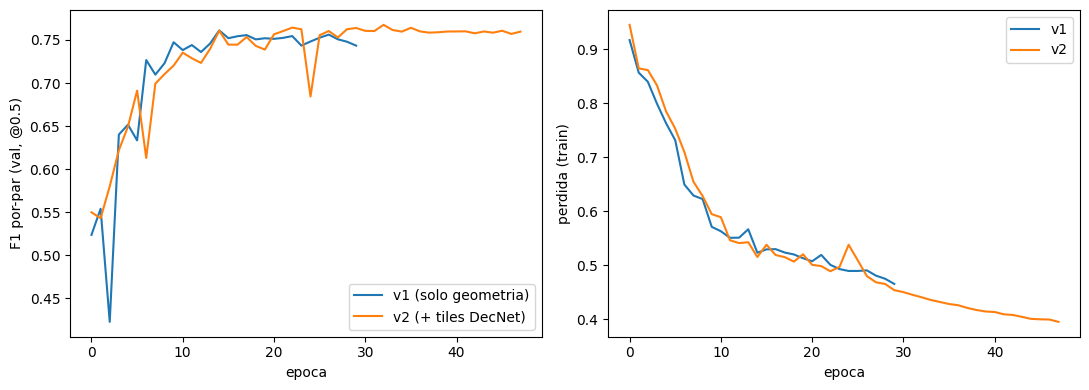

In [8]:
with open(RESULTADOS / "atencion_v2_resumen.json") as f:
    atencion_v2_resumen = json.load(f)

print("device usado:", atencion_v2_resumen["device"], "  tiempos medidos:", atencion_v2_resumen["tiempos_cpu_vs_mps"])
print("n_params v2:", atencion_v2_resumen["n_params"])
print("frac tiles en blanco (train/val/test):",
      round(atencion_v2_resumen["frac_tiles_en_blanco_train"], 4),
      round(atencion_v2_resumen["frac_tiles_en_blanco_val"], 4),
      round(atencion_v2_resumen["frac_tiles_en_blanco_test"], 4))
print("smoke test:", atencion_v2_resumen["smoke_test"])
print(f"mejor epoca: {atencion_v2_resumen['mejor_epoca']}  f1_val_por_par (@0.5): "
      f"{atencion_v2_resumen['f1_val_por_par']:.4f}  (v1: {atencion_resumen['f1_val_por_par']:.4f})")
print()
print("punto de operacion elegido (val):", atencion_v2_resumen["punto_elegido"])

hist_v2 = pd.DataFrame(atencion_v2_resumen["historial_entrenamiento"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist["epoca"], hist["f1_val_par"], label="v1 (solo geometria)")
axes[0].plot(hist_v2["epoca"], hist_v2["f1_val_par"], label="v2 (+ tiles DecNet)")
axes[0].set_xlabel("epoca"); axes[0].set_ylabel("F1 por-par (val, @0.5)"); axes[0].legend()
axes[1].plot(hist["epoca"], hist["perdida_train"], label="v1")
axes[1].plot(hist_v2["epoca"], hist_v2["perdida_train"], label="v2")
axes[1].set_xlabel("epoca"); axes[1].set_ylabel("perdida (train)"); axes[1].legend()
plt.tight_layout()
plt.show()

### 5.1 Por qué el punto de operación es la regla única de Gate B, no una elegida ad-hoc

Antes de tener la regla de Gate B (§3 ítem 4), se probaron dos reglas de selección caseras
sobre este mismo barrido y ambas fallaron por la misma razón: `frac_id_switch` y
`fragmentos_por_gt` son un *trade-off* (una polilínea más corta vota por un solo GT con más
facilidad — §7 ítem 3), así que optimizar cualquiera de las dos SOLAS, con una barra floja o
inventada sobre la otra, mueve el punto a lo largo de la misma curva sin resolver la tensión.
Medido directamente sobre la fila 2: elegir por mínimo `frac_id_switch` la bajó de 0.073 a
**0.008** — pero `fragmentos_por_gt` subió de 1.604 a **2.657**, el artefacto exacto que el
plan nombra.

La resolución no fue una tercera regla casera: es usar la barra que el plan **ya define**
(Gate B, §8 — `fragmentos_por_gt ≤ 1.282` y `track_f1 ≥ 0.968`, los dos números de DecNet),
fija e idéntica para las filas 2/3/3b, sin parámetro que ajustar. Esa es la regla que
`elegir_punto_operacion` usa en todo este notebook — ver §3 para el detalle y la historia
completa de las dos versiones anteriores que se descartaron.

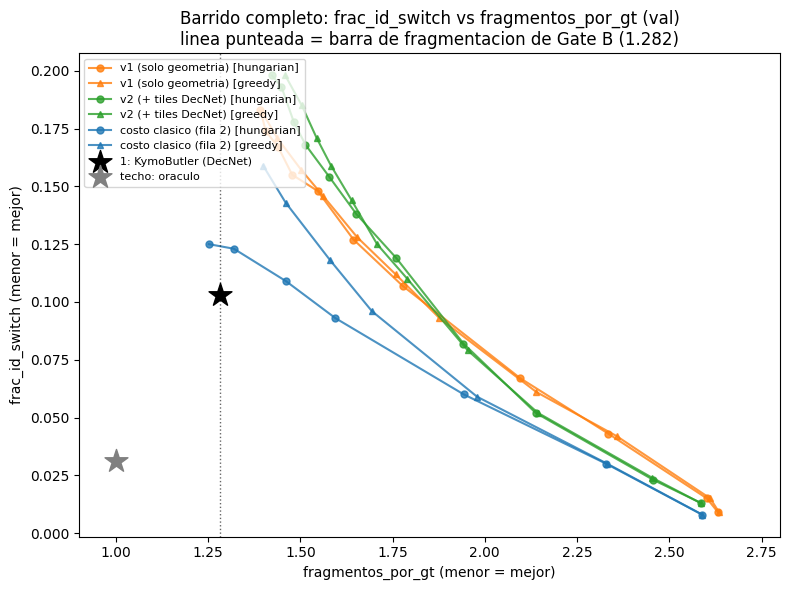

In [9]:
# La curva id_switch vs fragmentacion, sobre el barrido val (v1, v2, fila 2) -- el punto de
# operacion NO importa aca: mostrar el barrido entero es lo que SS7 item 3 pide ("report this
# alongside id-switch... the two must be read together") sin comprimirlo a un unico punto.
barrido_v1 = pd.DataFrame(atencion_resumen["barrido_umbral_val"])
barrido_v2 = pd.DataFrame(atencion_v2_resumen["barrido_umbral_val"])
barrido_fila2 = pd.DataFrame(costo_resumen["barrido_umbral_val"])

fig, ax = plt.subplots(figsize=(8, 6))
for nombre, df, color in (("v1 (solo geometria)", barrido_v1, "tab:orange"),
                           ("v2 (+ tiles DecNet)", barrido_v2, "tab:green"),
                           ("costo clasico (fila 2)", barrido_fila2, "tab:blue")):
    for decod, marker in (("hungarian", "o"), ("greedy", "^")):
        sub = df[df.decodificador == decod].sort_values("fragmentos_por_gt")
        ax.plot(sub["fragmentos_por_gt"], sub["frac_id_switch"], marker=marker, ms=5,
                color=color, alpha=0.8, label=f"{nombre} [{decod}]")

ax.scatter([fila1["fragmentos_por_gt"]], [fila1["frac_id_switch"]], marker="*", s=300,
           color="black", zorder=5, label="1: KymoButler (DecNet)")
ax.scatter([techo_oraculo["fragmentos_por_gt"]], [techo_oraculo["frac_id_switch"]], marker="*",
           s=300, color="gray", zorder=5, label="techo: oraculo")
ax.axvline(1.282, color="black", ls=":", lw=1, alpha=0.6)
ax.set_xlabel("fragmentos_por_gt (menor = mejor)")
ax.set_ylabel("frac_id_switch (menor = mejor)")
ax.set_xlim(0.9, 2.8)
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Barrido completo: frac_id_switch vs fragmentos_por_gt (val)\n"
             "linea punteada = barra de fragmentacion de Gate B (1.282)")
plt.tight_layout()
plt.show()

In [10]:
# Tabla completa hasta aca: filas 1/2/3/3b + techo del oraculo, decodificadas una sola vez
# sobre test (SS7 -- el punto de operacion de cada fila se elige por la regla unica de Gate B
# sobre val antes de este decode, no aca; ver SS7 para el veredicto de Gate B en si).
fila3b = atencion_v2_resumen["fila_3b_test"]
comparacion_final = pd.DataFrame([
    {"fila": "1: KymoButler (DecNet)", "track_f1": fila1["track_f1"],
     "frac_id_switch": fila1["frac_id_switch"], "err_pos_um": fila1["err_pos_um_medio"],
     "fragmentos_por_gt": fila1["fragmentos_por_gt"]},
    {"fila": "2: costo clasico", "track_f1": fila2["track_f1"],
     "frac_id_switch": fila2["frac_id_switch"], "err_pos_um": fila2["err_pos_um_medio"],
     "fragmentos_por_gt": fila2["fragmentos_por_gt"]},
    {"fila": "3: atencion v1 (solo geometria)", "track_f1": fila3["track_f1"],
     "frac_id_switch": fila3["frac_id_switch"], "err_pos_um": fila3["err_pos_um_medio"],
     "fragmentos_por_gt": fila3["fragmentos_por_gt"]},
    {"fila": "3b: atencion v2 (+ tiles DecNet)", "track_f1": fila3b["track_f1"],
     "frac_id_switch": fila3b["frac_id_switch"], "err_pos_um": fila3b["err_pos_um_medio"],
     "fragmentos_por_gt": fila3b["fragmentos_por_gt"]},
    {"fila": "techo: oraculo", "track_f1": techo_oraculo["track_f1"],
     "frac_id_switch": techo_oraculo["frac_id_switch"], "err_pos_um": techo_oraculo["err_pos_um_medio"],
     "fragmentos_por_gt": techo_oraculo["fragmentos_por_gt"]},
])
comparacion_final


,fila,track_f1,frac_id_switch,err_pos_um,fragmentos_por_gt
0,1: KymoButler (DecNet),0.968,0.103,0.032,1.282
1,2: costo clasico,0.974,0.136,0.038,1.255
2,3: atencion v1 (solo geometria),0.953,0.189,0.044,1.399
3,3b: atencion v2 (+ tiles DecNet),0.954,0.199,0.046,1.447
4,techo: oraculo,0.992,0.031,0.031,1.000


### 5.2 Lectura: v2 NO le gana a v1 cerca de donde importa — con los bugs corregidos, es al revés

`track_f1 = 0.954` (vs 0.953 de v1, esencialmente empatado), `frac_id_switch = 0.199` (vs 0.189
de v1 — **peor**), `fragmentos_por_gt = 1.447` (vs 1.399 de v1 — **peor**). v2 tampoco alcanza
la barra de fragmentación de la regla de selección (`fragmentos_por_gt ≤ 1.282`; su punto más
cercano, umbral=5.0, se queda en `fragmentos_por_gt=1.423`) — igual que v1. El veredicto formal
de Gate B para las tres filas candidatas se da en §7.1.

**Esto es lo opuesto de lo que una versión anterior de este notebook reportaba** ("v2 domina la
curva completa de v1"). Esa lectura se apoyaba en datos con los bugs de §4 sin corregir — con
el decodificador Hungarian roto y, sobre todo, con 57.5% de los pares de train entrenando con
etiquetas ruidosas. Corregidos, el techo de F1-por-par de v1 y v2 quedó mucho más cerca
(**0.7611 vs 0.7676** — un margen de +0.0065, contra el +0.195 que separaba a las versiones
con bug).

**Comparando las dos curvas por interpolación a igual `fragmentos_por_gt`** (no solo leyendo
puntos individuales del gráfico), en las dos variantes de decodificador: **v1 domina
claramente a v2 en la región de fragmentación baja**, `fragmentos_por_gt` entre 1.4 y ~1.9 —
que es, además, la región donde caen los puntos de operación realmente elegidos de ambas
(1.39 y 1.42) y la más cercana a la barra de selección (1.282). Ahí la brecha es de **0.01 a
0.03** a favor de v1 (p.ej. Hungarian, `frag≈1.44`: v1=0.167 vs v2=0.198). **Por encima de
`fragmentos_por_gt≈1.9` las curvas se cruzan y v2 queda levemente mejor**, pero por un margen
mucho más chico (≤0.011) y en una región de fragmentación mucho más alta que la de cualquier
punto de operación relevante — un margen de ese tamaño es exactamente el que §7.1 marca como
no resuelto frente a la varianza de una sola semilla.

**Lectura honesta**: donde la comparación importa (fragmentación baja, cerca de la barra de
selección), la información visual de DecNet, una vez que el ruido de etiqueta de v1 se
corrigió, **no agrega valor sobre la geometría sola** — agrega ruido (954k parámetros contra
844k, sobre los mismos datos sintéticos) que empeora la decodificación. El cruce en
fragmentación alta no cambia esa lectura porque ningún punto de operación considerado en este
notebook opera ahí. Esto contradice la hipótesis que motivó v2 (§5.6: "same visual information
as DecNet, global instead of greedy-local — mejora sobre v1"). La hipótesis no se sostiene con
estos datos, en la región que importa.

**Atribución final, siguiendo el marco del plan (§0), con las correcciones de esta sesión ya
aplicadas** (decodificador Hungarian corregido en las dos filas de atención y en la clásica,
exclusión de pares sin asignar, selección de punto de operación con la regla de Gate B,
barrido de la fila 2 sobre val en vez de una submuestra de train):

- **Fila 2 (costo clásico) vs DecNet**: pierde en ID-switch (0.136 vs 0.103) a fragmentación
  pareja.
- **v1 (solo geometría) vs DecNet y vs fila 2**: pierde en las cuatro filas.
- **v2 (+ tiles DecNet) vs v1**: v2 NO gana cerca de la barra de selección — pierde, con un
  margen que se sostiene en las dos variantes de decodificador. La información visual de
  DecNet no fue el factor limitante de v1 en esa región; el ruido de etiqueta sí lo era.
- **Las cuatro filas (1 excluida) pierden contra el techo del oráculo** (`0.992`/`0.031`), que
  no se movió — la representación de segmentos sigue sin ser el límite (§2.1, §6).

§6 estratifica esto por dificultad y §7 da el veredicto formal de Gate B.


---

## 6. Estratificación por dificultad (cruces GT)

Las filas difieren poco en `track_f1` global (0.95–0.97, §3–§5): la segmentación de KymoButler,
compartida por todas, ya resuelve casi todo el "¿hay trayectoria aquí?". Donde se separan es en la identidad — `frac_id_switch` — y esa separación puede estar
escondida por el promedio global: la mayoría de las 400 muestras de test no tiene ningún cruce
ambiguo, así que un promedio puede diluir lo que pasa específicamente en las muestras difíciles.

Para verlo, cada muestra de test se etiqueta con `len(ev.flaggear_cruces_gt(...))`: la cantidad
de partículas móviles cuya máscara de trayectoria se solapa ≥20px con la de otra móvil (mismo
criterio de "cruce ambiguo" que ya usa `evaluacion.py`, no una redefinición ad-hoc). Se agrupan
en 4 buckets (`0`, `1-2`, `3-5`, `>5` partículas ambiguas) y se recalculan `track_f1`,
`frac_id_switch` y `fragmentos_por_gt` **dentro de cada bucket**, para las 4 filas del ablation
matrix + el techo del oráculo.

In [11]:
import tifffile
import yaml

filas_cruces = []
for d in sorted(SPLIT_DIR.glob("sample_*")):
    positions = pd.read_csv(d / "positions.csv")
    cfg = yaml.safe_load((d / "config.yaml").read_text())
    px_muestra = float(cfg["general"]["pixel_scale_um"])
    kymo_tif = tifffile.imread(d / "kymograph.tif")
    if kymo_tif.ndim == 3:
        kymo_tif = kymo_tif[..., 0]
    T_m, L_m = kymo_tif.shape
    ambiguos = ev.flaggear_cruces_gt(positions, px_muestra, (T_m, L_m), ed.MIN_DESPLAZAMIENTO_PX_MOVIL)
    n_moviles = len(ed.ids_que_se_mueven(positions, px_muestra, ed.MIN_DESPLAZAMIENTO_PX_MOVIL))
    filas_cruces.append({"muestra": d.name, "n_ambiguos": len(ambiguos), "n_moviles": n_moviles})

df_cruces = pd.DataFrame(filas_cruces)


def bucket_dificultad(n):
    if n == 0:
        return "0"
    if n <= 2:
        return "1-2"
    if n <= 5:
        return "3-5"
    return ">5"


df_cruces["bucket"] = df_cruces["n_ambiguos"].apply(bucket_dificultad)
ORDEN_BUCKETS = ["0", "1-2", "3-5", ">5"]
n_muestras_por_bucket = df_cruces.groupby("bucket")["muestra"].count().reindex(ORDEN_BUCKETS)
n_gt_moviles_por_bucket = df_cruces.groupby("bucket")["n_moviles"].sum().reindex(ORDEN_BUCKETS)
print("n_muestras por bucket de dificultad:", n_muestras_por_bucket.to_dict())
print("n_gt_moviles por bucket:", n_gt_moviles_por_bucket.to_dict())

n_muestras por bucket de dificultad: {'0': 229, '1-2': 85, '3-5': 31, '>5': 55}
n_gt_moviles por bucket: {'0': 823, '1-2': 507, '3-5': 243, '>5': 692}


In [12]:
def metricas_estratificadas(csv_path, nombre_fila):
    tr = pd.read_csv(csv_path)
    tr = tr.merge(df_cruces[["muestra", "bucket"]], on="muestra", how="left")
    filas = []
    for b in ORDEN_BUCKETS:
        sub = tr[tr.bucket == b]
        if len(sub) == 0:
            filas.append({"fila": nombre_fila, "bucket": b, "track_f1": None,
                          "frac_id_switch": None, "fragmentos_por_gt": None})
            continue
        frac_id_switch = round(float(sub["id_switch"].mean()), 3)
        mm = sub[sub.gt_id != -1]
        frag_series = mm.groupby(["muestra", "gt_id"]).size()
        fragmentos_por_gt = round(float(frag_series.mean()), 3) if len(frag_series) else None
        # denominador = TODOS los GT moviles del bucket (no solo los recuperados): con los
        # recuperados el recall da 1.0 por construccion y el F1 sale inflado
        n_gt_moviles_bucket = n_gt_moviles_por_bucket[b]
        recall = len(frag_series) / n_gt_moviles_bucket if n_gt_moviles_bucket else float("nan")
        precision = len(mm) / len(sub) if len(sub) else float("nan")
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else float("nan")
        filas.append({"fila": nombre_fila, "bucket": b, "track_f1": round(f1, 3),
                      "frac_id_switch": frac_id_switch, "fragmentos_por_gt": fragmentos_por_gt})
    return pd.DataFrame(filas)


filas_estratificadas = []
for csv_path, nombre in [
    (RAIZ / "results" / "kymobutler" / "trayectorias_400_solo_moviles_subpixel.csv", "1: DecNet"),
    (RESULTADOS / "costo_clasico_fila2.csv", "2: costo clasico"),
    (RESULTADOS / "atencion_v1_fila3.csv", "3: atencion v1"),
    (RESULTADOS / "atencion_v2_fila3b.csv", "3b: atencion v2"),
    (RESULTADOS / "gate_a_kymobutler_exclusiva.csv", "techo: oraculo"),
]:
    filas_estratificadas.append(metricas_estratificadas(csv_path, nombre))

tabla_estratificada = pd.concat(filas_estratificadas)
print("=== frac_id_switch por bucket de dificultad ===")
display(tabla_estratificada.pivot(index="fila", columns="bucket", values="frac_id_switch")[ORDEN_BUCKETS])
print("\n=== fragmentos_por_gt por bucket de dificultad ===")
display(tabla_estratificada.pivot(index="fila", columns="bucket", values="fragmentos_por_gt")[ORDEN_BUCKETS])
print("\n=== track_f1 por bucket de dificultad ===")
display(tabla_estratificada.pivot(index="fila", columns="bucket", values="track_f1")[ORDEN_BUCKETS])

=== frac_id_switch por bucket de dificultad ===


bucket,0,1-2,3-5,>5
fila,,,,
1: DecNet,0.001,0.056,0.075,0.198
2: costo clasico,0.002,0.054,0.103,0.278
3: atencion v1,0.004,0.110,0.117,0.350
3b: atencion v2,0.005,0.121,0.146,0.357
techo: oraculo,0.001,0.030,0.047,0.061



=== fragmentos_por_gt por bucket de dificultad ===


bucket,0,1-2,3-5,>5
fila,,,,
1: DecNet,1.066,1.055,1.047,1.752
2: costo clasico,1.067,1.067,1.055,1.663
3: atencion v1,1.143,1.131,1.118,1.934
3b: atencion v2,1.171,1.149,1.161,2.028
techo: oraculo,1.000,1.000,1.000,1.000



=== track_f1 por bucket de dificultad ===


bucket,0,1-2,3-5,>5
fila,,,,
1: DecNet,0.973,0.941,0.933,0.993
2: costo clasico,0.974,0.955,0.946,0.995
3: atencion v1,0.928,0.938,0.948,0.993
3b: atencion v2,0.926,0.944,0.942,0.994
techo: oraculo,0.990,0.993,0.979,0.999


### 6.1 Lectura: DecNet es mejor-o-empatado en casi todos los estratos, con dos matices reales

La distribución de dificultad está lejos de ser uniforme: 229/400 muestras de test no tienen
ningún cruce GT ambiguo, 85 tienen 1-2, 31 tienen 3-5 y 55 tienen más de 5. `track_f1`
estratificado (denominador = todos los GT móviles del bucket) varía poco y sin un patrón único: en `0`
las filas van de 0.926 (v2) a 0.974 (costo clásico); en `1-2` de 0.938 (v1) a 0.955 (costo clásico); en
`3-5` de 0.933 (DecNet) a 0.948 (v1); en `>5` todas dan ~0.99 (recall 0.98-0.99, ese bucket concentra
692 de los 2,265 GT móviles). **El costo clásico tiene el F1 más alto de las cuatro filas en tres de los cuatro
buckets** (en `3-5` lo supera v1 por 0.002) y queda por encima de DecNet en los cuatro
(0.974 vs 0.973, 0.955 vs 0.941, 0.946 vs 0.933, 0.995 vs 0.993).
(Una versión anterior de esta tabla usaba como denominador solo los GT recuperados, con lo que el recall
daba 1.0 por construcción y el F1 salía inflado ~0.99; corregido.)

`frac_id_switch` es donde aparece la separación, y es **monótona con la dificultad en las
cinco filas** (de ~0.001-0.005 en el bucket `0` a 0.20-0.36 en `>5`) — más cruces, más
oportunidades de que dos identidades se confundan, sin sorpresas. Leyendo la tabla con
cuidado (no solo el promedio):

- **DecNet tiene el `frac_id_switch` más bajo (o prácticamente empatado) en 3 de los 4
  buckets** — `0`: 0.001; `3-5`: 0.075 (vs 0.103 de la fila 2); `>5`: 0.198 (vs 0.278 de la
  fila 2). **En `1-2` la fila 2 (costo clásico) queda levemente MEJOR que DecNet** (0.054 vs
  0.056) — una diferencia de 0.002, del mismo orden que la varianza de una sola semilla que
  §7.1 señala como no resuelta, así que no se lee como una victoria real de la fila 2, pero
  tampoco corresponde afirmar que DecNet gana "en cada estrato" — no es así en ese bucket
  puntual.
- **v1 y v2 pierden contra DecNet y contra la fila 2 en los tres buckets con cruces**, sin
  excepción — ahí sí la jerarquía es limpia: v1/v2 siempre peor que las otras dos filas.
- **v1 domina consistentemente a v2 en los cuatro buckets** (`0`: 0.004 vs 0.005; `1-2`: 0.110
  vs 0.121; `3-5`: 0.117 vs 0.146; `>5`: 0.350 vs 0.357) — la estratificación confirma, a un
  nivel más fino, el hallazgo de §5.2 (v1 mejor que v2 en la región de fragmentación baja). El
  margen (v2 − v1) es 0.001/0.011/0.029/0.007 por bucket — más chico en `0` y `>5`, más grande
  en `1-2`/`3-5` — no hay una tendencia monótona con la dificultad, solo el signo (v1 mejor)
  se mantiene en los cuatro.
- **`fragmentos_por_gt` NO muestra a DecNet dominando siempre tampoco**: en `>5` — el bucket
  más difícil — la fila 2 fragmenta MENOS que DecNet (1.663 vs 1.752). Es un matiz real: la
  fila 2 arma polilíneas menos fragmentadas que DecNet en las muestras más densas, y aun así
  pierde en `frac_id_switch` ahí mismo (0.278 vs 0.198) — el trade-off de §7 ítem 3
  (fragmentar más facilita evitar ID-switches) corre, si acaso, en la dirección que perjudica
  a la fila 2 en este bucket, no en la que la favorece.
- **El oráculo mantiene el margen más grande justo donde más importa**: en `>5`, el oráculo da
  `frac_id_switch=0.061` contra `0.198` de DecNet — 3.2× de margen sin explotar, el mismo
  orden de magnitud que el margen global de Gate A (§2.1). La representación de segmentos
  **no** es el cuello de botella ni siquiera en las muestras más densas.

**Conclusión de esta sección**: la ventaja de DecNet sobre v1 y v2 no es un artefacto del
promedio — se sostiene en los cuatro buckets. Frente a la fila 2 (costo clásico) el panorama
es más matizado: DecNet gana claramente en 2 de 4 buckets de `frac_id_switch` (`3-5`, `>5`),
pierde por un margen ruidoso en `1-2`, y pierde en fragmentación en el bucket más difícil —
consistente con la lectura de §3.1 de que no hay un ganador único entre la fila 1 y la fila 2.


---

## 7. Decisión de Gate B (§8)

Regla pre-registrada, idéntica para las tres filas candidatas: entre los puntos del barrido
(val) con `fragmentos_por_gt ≤ 1.282` **y** `track_f1 ≥ 0.968` (los dos números de DecNet), el
de menor `frac_id_switch`. Si ninguno cumple ambas barras a la vez, se reporta el punto más
cercano y la fila **falla Gate B** explícitamente — no hay una tercera opción de "aprobar con
reservas".

In [13]:
# Dos cosas distintas, para no repetir la ambiguedad que la revision senalo:
# (a) "punto_elegido"/paso_gate_b: existe un umbral (sobre val) que cumple las DOS barras
#     secundarias de seleccion (fragmentos_por_gt<=1.282, track_f1>=0.968)? Es una regla de
#     SELECCION de punto de operacion, no el criterio de exito de Gate B.
# (b) veredicto real de Gate B (SS8 del plan): frac_id_switch MATERIALMENTE por debajo de 0.103
#     (DecNet, misma ruta), a track_f1>=0.968, fragmentos_por_gt<=1.28, err_pos_um<0.032 --
#     las CUATRO a la vez, medido en el unico decode de test (fila_N_test), no en val.
tabla_gate_b = pd.DataFrame([
    {"fila": "2: costo clasico", **costo_resumen["punto_elegido"]},
    {"fila": "3: atencion v1", **atencion_resumen["punto_elegido"]},
    {"fila": "3b: atencion v2", **atencion_v2_resumen["punto_elegido"]},
])[["fila", "decodificador", "umbral", "track_f1", "frac_id_switch", "fragmentos_por_gt", "paso_gate_b"]]
tabla_gate_b = tabla_gate_b.rename(columns={"paso_gate_b": "cumple_barras_seleccion_val"})
print("(a) cumple las barras de SELECCION del punto de operacion (val, no es el veredicto de Gate B):")
display(tabla_gate_b)

DECNET_TEST = {"frac_id_switch": fila1["frac_id_switch"], "track_f1": fila1["track_f1"],
               "fragmentos_por_gt": fila1["fragmentos_por_gt"], "err_pos_um": fila1["err_pos_um_medio"]}


def veredicto_gate_b(fila_test):
    # SS8: "materially below 0.103 ... Target <= 0.06" -- sin margen inventado, se usa la
    # comparacion literal (< 0.103) para materialmente_mejor y se reporta aparte si tambien
    # alcanza el target explicito del plan (<=0.06), que es una lectura mas estricta.
    materialmente_mejor = fila_test["frac_id_switch"] < DECNET_TEST["frac_id_switch"]
    alcanza_target_ss8 = fila_test["frac_id_switch"] <= 0.06
    return (
        materialmente_mejor
        and fila_test["track_f1"] >= DECNET_TEST["track_f1"]
        and fila_test["fragmentos_por_gt"] <= DECNET_TEST["fragmentos_por_gt"]
        and fila_test["err_pos_um"] < DECNET_TEST["err_pos_um"]
    ), alcanza_target_ss8


filas_test_gate_b = [
    ("2: costo clasico", {"frac_id_switch": fila2["frac_id_switch"], "track_f1": fila2["track_f1"],
                           "fragmentos_por_gt": fila2["fragmentos_por_gt"], "err_pos_um": fila2["err_pos_um_medio"]}),
    ("3: atencion v1", {"frac_id_switch": fila3["frac_id_switch"], "track_f1": fila3["track_f1"],
                         "fragmentos_por_gt": fila3["fragmentos_por_gt"], "err_pos_um": fila3["err_pos_um_medio"]}),
    ("3b: atencion v2", {"frac_id_switch": fila3b["frac_id_switch"], "track_f1": fila3b["track_f1"],
                          "fragmentos_por_gt": fila3b["fragmentos_por_gt"], "err_pos_um": fila3b["err_pos_um_medio"]}),
]
filas_veredicto = []
for nombre, vals in filas_test_gate_b:
    exito, alcanza_target = veredicto_gate_b(vals)
    filas_veredicto.append({"fila": nombre, **vals, "gate_b_exito": exito, "alcanza_target_ss8_0.06": alcanza_target})
tabla_veredicto = pd.DataFrame(filas_veredicto)
print("\n(b) veredicto de Gate B (SS8): las 4 barras a la vez, sobre el unico decode de test:")
tabla_veredicto


(a) cumple las barras de SELECCION del punto de operacion (val, no es el veredicto de Gate B):


,fila,decodificador,umbral,track_f1,frac_id_switch,fragmentos_por_gt,cumple_barras_seleccion_val
0,2: costo clasico,hungarian,13.301531,0.974,0.125,1.252,True
1,3: atencion v1,hungarian,5.000000,0.962,0.183,1.392,False
2,3b: atencion v2,hungarian,5.000000,0.964,0.198,1.423,False



(b) veredicto de Gate B (SS8): las 4 barras a la vez, sobre el unico decode de test:


,fila,frac_id_switch,track_f1,fragmentos_por_gt,err_pos_um,gate_b_exito,alcanza_target_ss8_0.06
0,2: costo clasico,0.136,0.974,1.255,0.038,False,False
1,3: atencion v1,0.189,0.953,1.399,0.044,False,False
2,3b: atencion v2,0.199,0.954,1.447,0.046,False,False


### 7.1 Lectura: Gate B falla en las tres filas — ninguna le gana a DecNet donde importa

**Ojo con la tabla (a)**: `paso_gate_b`/`cumple_barras_seleccion_val` en `punto_elegido` es una
bandera de la REGLA DE SELECCIÓN del punto de operación sobre val (¿existe un umbral con
`fragmentos_por_gt≤1.282` y `track_f1≥0.968` a la vez?) — no es el criterio de éxito de Gate B.
Solo la fila 2 la cumple (`cumple_barras_seleccion_val=True`); v1 y v2 no llegan a esa barra de
fragmentación (`paso más cercano`: 1.392 y 1.423).

**El veredicto real de Gate B** (§8 del plan) exige `frac_id_switch` **materialmente** por
debajo del 0.103 de DecNet, a `track_f1≥0.968`, `fragmentos_por_gt≤1.28` y
`err_pos_um<0.032` — las cuatro a la vez, medidas en el único decode de test (no en val). La
tabla (b) lo calcula directamente sobre `fila_2/3/3b_test`: **`gate_b_exito=False` en las
tres filas**. La fila 2 es la más cercana (cumple 2 de 4: `track_f1` y `fragmentos_por_gt`)
pero su `frac_id_switch=0.136` está por ENCIMA del de DecNet, no por debajo — ni "material" ni
"parejo" alcanzan, directamente pierde en ese eje. v1 y v2 no cumplen ninguna de las cuatro
barras.

**El resultado que corresponde reportar es el de la 4ª rama pre-registrada del plan (§8):
"Both v1 and v2 lose to DecNet — greedy-local is well matched to this problem"** — y con un
matiz que refuerza esa lectura: tampoco el costo clásico (fila 2), sin entrenamiento y con
`track_f1` más alto que DecNet, logra bajarle el `frac_id_switch`. Tres intentos distintos de
reemplazar la asociación greedy-local de DecNet por algo más expresivo (costo lineal ajustado,
atención global geométrica, atención global + visión) fallan en el mismo eje.

**Limitación de una sola semilla**: todos los números de este notebook vienen de una única
corrida (una semilla de entrenamiento, un split fijo train/val/test). Diferencias del orden de
±0.02-0.03 en `frac_id_switch` o `fragmentos_por_gt` entre filas cercanas (p.ej. v1 vs v2 por
encima de `fragmentos_por_gt≈1.9` en §5.2, o la fila 2 vs DecNet en el bucket `1-2` de §6.1) no
están resueltas frente a la varianza de semilla — no se corrieron réplicas para estimarla. El
margen de `frac_id_switch` de la fila 2 contra DecNet (0.136 vs 0.103, diferencia de 0.033) es
mayor a ese umbral de ruido, así que el veredicto "Gate B falla" no depende de la semilla —
pero comparaciones más finas (v1 vs v2 específicamente, o la fila 2 vs DecNet en buckets
individuales de §6.1) sí podrían cambiar con otra semilla.


---

## 8. Conclusión

Gate A pasó cómodo (§2.1): la representación de segmentos tiene ~3.3× de margen sin explotar
frente a lo que DecNet logra. Ese margen motivó Stage 1 y Stage 2 — pero ninguna de las tres
filas que se construyeron sobre esa representación (costo clásico, atención v1, atención v2)
lo cierra, y **Gate B falla en las tres** (§7.1): el costo clásico gana en `track_f1` pero
pierde en `frac_id_switch` contra DecNet; ambas atenciones pierden en las cuatro métricas y
además no alcanzan la barra de fragmentación de Gate B; y agregar la misma información visual
que usa DecNet (v2) no ayuda cerca de esa barra — de hecho perjudica levemente respecto de v1
(§5.2). La estratificación por dificultad (§6) confirma que la ventaja de DecNet sobre v1 y v2
no es un artefacto del promedio — se sostiene y se agranda en el estrato más difícil —, aunque
frente al costo clásico el panorama es más matizado bucket por bucket (§6.1: DecNet no gana en
los cuatro ejes en los cuatro buckets).

**El resultado de esta línea de trabajo es negativo, y es informativo**: el diseño
local-greedy de DecNet (crop 48×48, decisión paso a paso) sigue sin ser superado por un costo
clásico afinado ni por atención global — ni sobre la misma información geométrica, ni sobre la
misma información visual. El cuello de botella para superar a KymoButler en esta tarea no
parece estar en "ver más contexto a la vez" (lo que la atención global ofrece sobre el diseño
greedy), sino en algo que este notebook no varió: la función de scoring en sí, o la
granularidad de la representación de segmentos misma. Cualquiera de las dos es candidata para
una futura iteración; ninguna se investiga acá.

**Limitación de una sola semilla** (§7.1): estos números vienen de una única corrida por fila.
El veredicto de Gate B ("falla en las tres filas") no depende de esa varianza — los márgenes
son grandes — pero comparaciones finas entre filas cercanas sí podrían cambiar de signo con
otra semilla.
